In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(GenomeInfoDb)
library(EnsDb.Mmusculus.v79)
library(stringr)
library(tibble)
library(BSgenome.Mmusculus.UCSC.mm10)
library(clusterProfiler)
library(org.Mm.eg.db)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aper

In [2]:
setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig2')

#### Figures 2i-2l: Isocortex aging-associated chromatin and transcriptional signatures

In [3]:
merged_obj <- readRDS('processed_data/aging_brain_merged_registered_tiled.rds')

In [4]:
peaks_obj_list <- readRDS('processed_data/aging_brain_differential_peak_objects.rds')

##### Figure 2i: H3K4me1 module score

In [5]:
h3k4me1_peaks <- read.table(
  'processed_data/differential_peaks/isocortex/h3k4me1_24m_vs_3m_DE_peaks.bed',
  header = TRUE,
  sep = '\t',
  row.names = 1
)

all_h3k4me1_peaks <- rownames(
  peaks_obj_list[['isocortex']]@assays$h3k4me1_Spatial_Tile_newpeaks_broad_perage
)

all(rownames(h3k4me1_peaks) %in% all_h3k4me1_peaks)

[1] TRUE

In [6]:
assay_plot <- 'h3k4me1_Spatial_Tile'

In [7]:
new_mtx <- FeatureMatrix(
  Fragments(merged_obj[[assay_plot]]),
  features = all_h3k4me1_peaks
)

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



In [8]:
merged_obj[['plot_assay']] <- CreateChromatinAssay(
  counts = new_mtx,
  fragments = Fragments(merged_obj[[assay_plot]]),
  genome = 'mm10'
)

In [9]:
merged_obj <- AddChromatinModule(
  merged_obj,
  assay = 'plot_assay',
  features = list('peak_module' = rownames(h3k4me1_peaks)),
  genome = BSgenome.Mmusculus.UCSC.mm10,
  verbose = FALSE
)

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."


Warning message:
"Removing 4450 cells missing data for vars requested"
Warning message:
"Removing 216 cells missing data for vars requested"
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


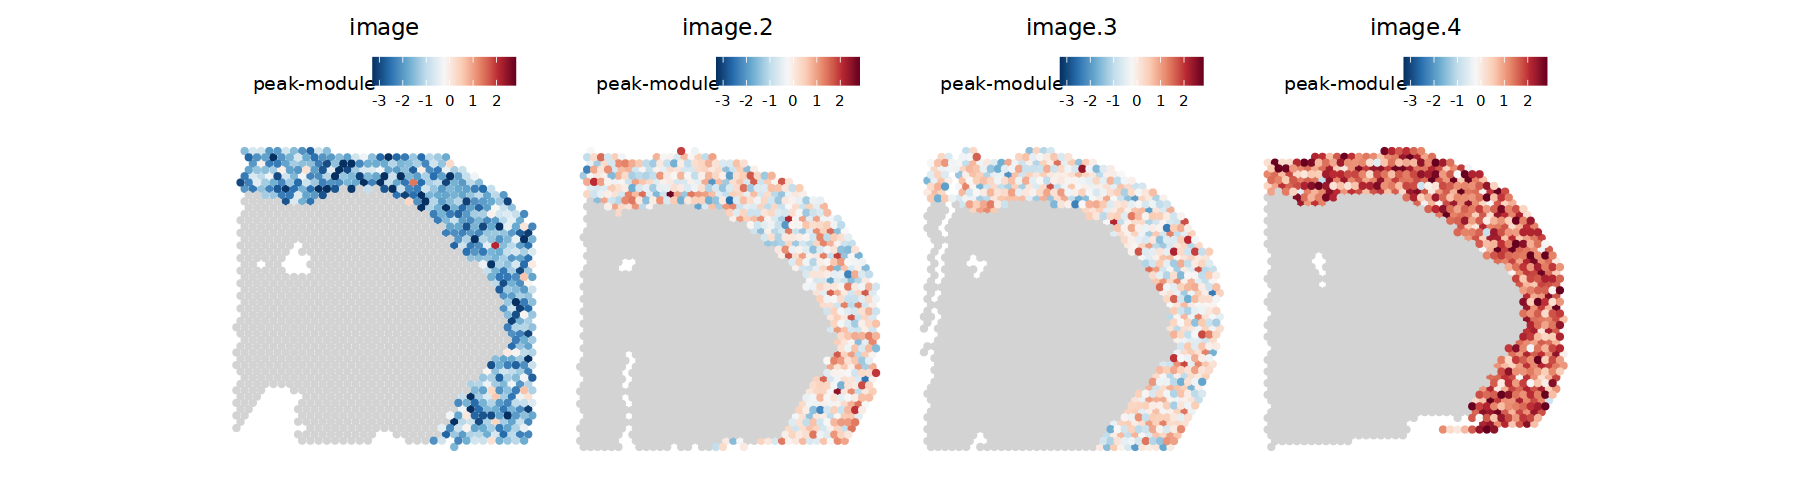

In [21]:
options(repr.plot.width = 15, repr.plot.height = 4)
palette <- jdb_palette('brewer_yes')
vals <- FetchData(merged_obj, vars = 'peak-module')[, 1]
minv <- quantile(vals, na.rm = TRUE, prob = 0.01)
maxv <- quantile(vals, na.rm = TRUE, prob = 0.99)
highlight_cells <- WhichCells(merged_obj, expression = (annotation_assigned != 'isocortex'))
merged_obj@meta.data[highlight_cells, 'peak-module'] <- NA
merged_obj@meta.data[is.na(merged_obj@meta.data$annotation_assigned), 'peak-module'] <- NA
p <- SpatialFeaturePlot(merged_obj, features = 'peak-module', pt.size.factor = 6) &
  scale_fill_gradientn(colors = palette, limits = c(minv, maxv), oob = scales::squish, na.value = 'lightgrey')
p

In [11]:
gene_module <- read.table(
  'processed_data/isocortex_synaptic_gene_list.txt',
  header = FALSE,
  stringsAsFactors = FALSE
)$V1

##### Figure 2j: Module scores for genes associated with peaks

In [15]:
DefaultAssay(merged_obj) <- 'RNA_Spatial'
merged_obj <- AddModuleScore(
  merged_obj,
  features = list('synaptic_module' = gene_module),
  name = 'synaptic_module'
)

Warning message:
"Removing 4450 cells missing data for vars requested"
Warning message:
"Removing 216 cells missing data for vars requested"


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


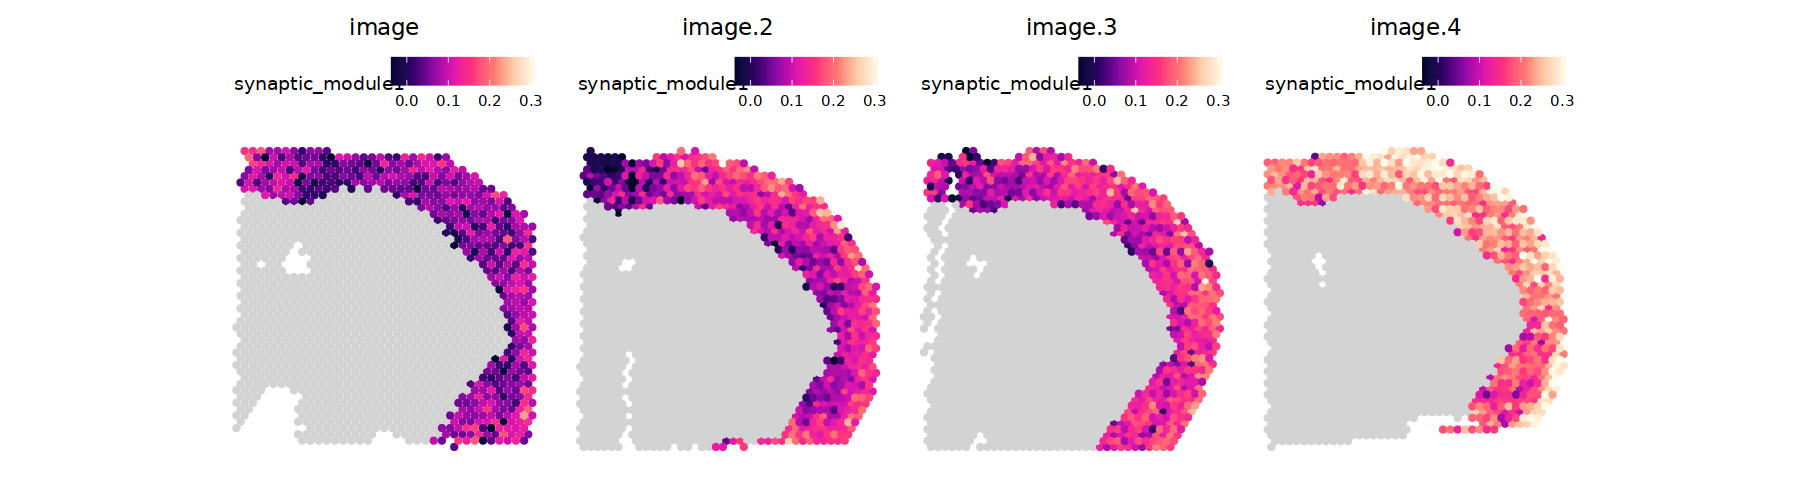

In [22]:
options(repr.plot.width = 15, repr.plot.height = 4)
palette <- jdb_palette('china_weirdo')
vals <- FetchData(merged_obj, vars = 'synaptic_module1')[, 1]
minv <- quantile(vals, na.rm = TRUE, prob = 0.01)
maxv <- quantile(vals, na.rm = TRUE, prob = 0.99)
highlight_cells <- WhichCells(merged_obj, expression = (annotation_assigned != 'isocortex'))
merged_obj@meta.data[highlight_cells, 'synaptic_module1'] <- NA
merged_obj@meta.data[is.na(merged_obj@meta.data$annotation_assigned), 'synaptic_module1'] <- NA
p <- SpatialFeaturePlot(merged_obj, features = 'synaptic_module1', pt.size.factor = 6) &
  scale_fill_gradientn(colors = palette, limits = c(minv, maxv), oob = scales::squish, na.value = 'lightgrey')
p

##### Figure 2k: GO overrepresentation analysis on the gene module

In [12]:
go_res <- enrichGO(
  gene = gene_module,
  OrgDb = org.Mm.eg.db,
  keyType = 'SYMBOL',
  ont = 'BP',
  minGSSize = 5,
  maxGSSize = 500,
  pvalueCutoff = 0.1
)

simplified_res <- simplify(go_res, cutoff = 0.4, by = 'p.adjust', select_fun = min)

In [13]:
makebarplot <- function(data, title, numpoints) {
  data[['log10_pvalue']] <- -log10(data$pvalue)
  data_plot_df <- dplyr::arrange(data, desc(log10_pvalue))[1:numpoints, ]
  data_plot_df$Description <- apply(str_split_fixed(data_plot_df$Description, '_', Inf), 1, paste, collapse = ' ') %>% tolower()
  data_plot_df$Description <- str_wrap(data_plot_df$Description, width = 30)
  data_plot_df$Description <- factor(data_plot_df$Description, levels = rev(data_plot_df$Description))

  plot <- ggplot(data_plot_df, aes(x = log10_pvalue, y = Description)) +
    geom_bar(stat = 'identity') +
    xlab(bquote(~-Log[10] ~ 'p value')) +
    ylab(NULL) +
    ggtitle(title) +
    theme_bw() +
    theme(
      plot.title = element_text(hjust = 0.5, size = 17, face = 'bold'),
      axis.text.y = element_text(size = 14),
      panel.border = element_blank(),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      axis.line = element_line(colour = 'black')
    )

  return(plot)
}

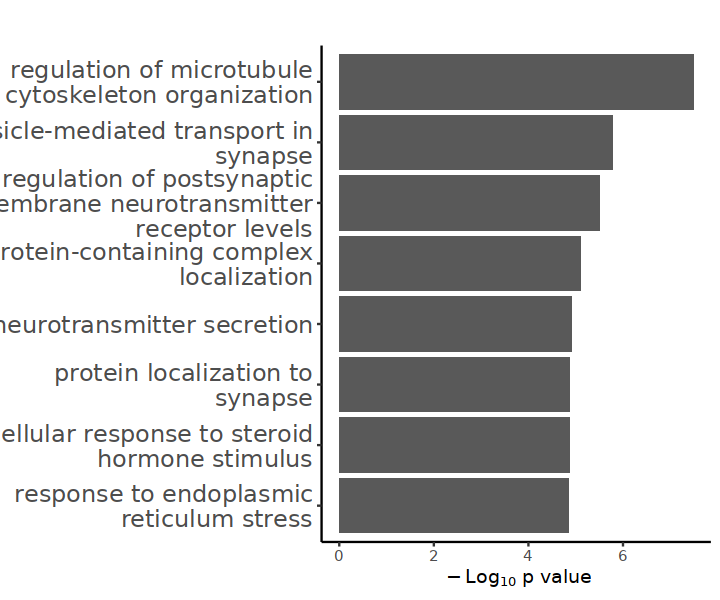

In [14]:
options(repr.plot.width = 6, repr.plot.height = 5)
p <- makebarplot(simplified_res@result, title = '', 8)
print(p)

##### Figure 2l: Egr spatial expression

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


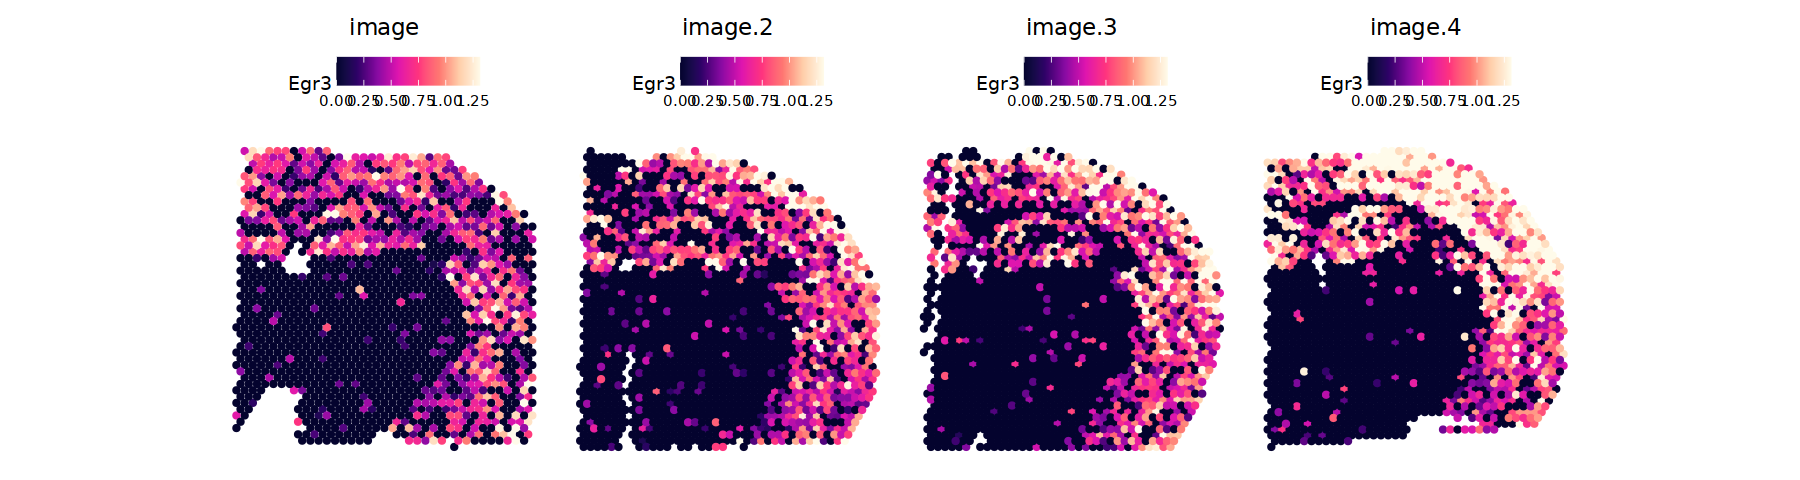

In [18]:
options(repr.plot.width = 15, repr.plot.height = 4)
palette <- jdb_palette('china_weirdo')
vals <- FetchData(merged_obj, vars = 'Egr3')[, 1]
minv <- quantile(vals, na.rm = TRUE, prob = 0.05)
maxv <- quantile(vals, na.rm = TRUE, prob = 0.95)
p <- SpatialFeaturePlot(merged_obj, features = 'Egr3', pt.size.factor = 6) &
  scale_fill_gradientn(colors = palette, limits = c(minv, maxv), oob = scales::squish)
print(p)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


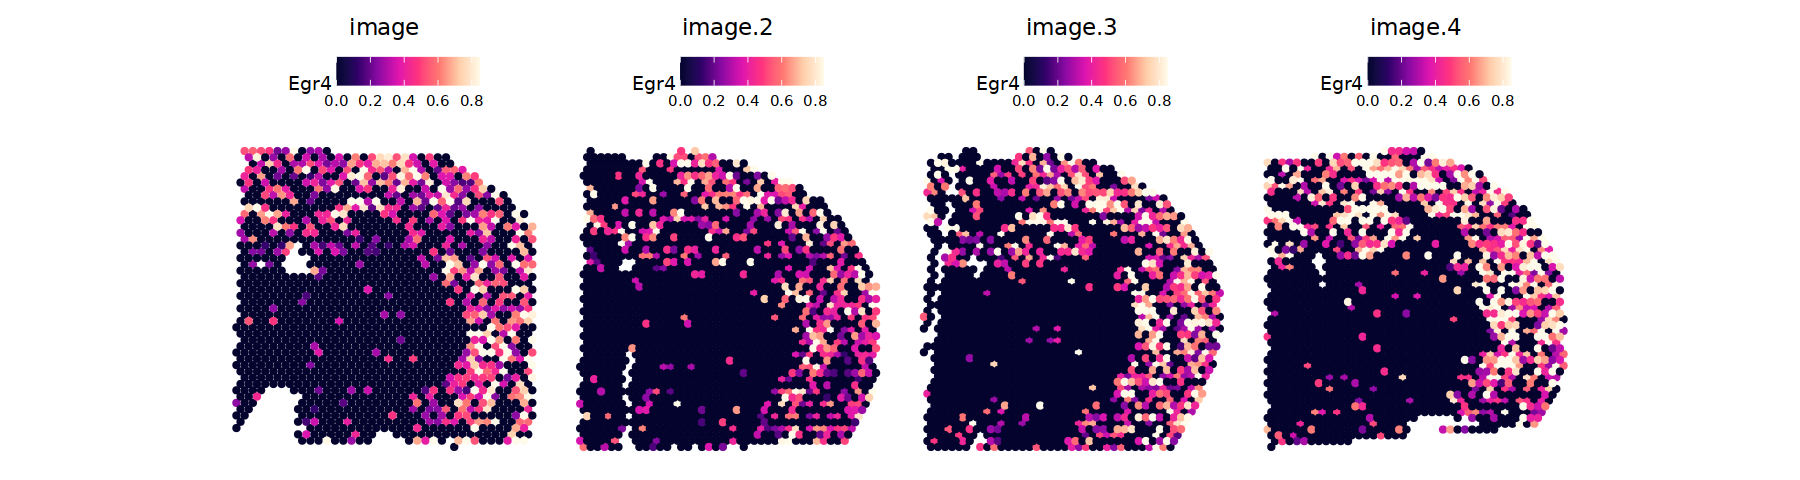

In [19]:
options(repr.plot.width = 15, repr.plot.height = 4)
palette <- jdb_palette('china_weirdo')
vals <- FetchData(merged_obj, vars = 'Egr4')[, 1]
minv <- quantile(vals, na.rm = TRUE, prob = 0.05)
maxv <- quantile(vals, na.rm = TRUE, prob = 0.95)
p <- SpatialFeaturePlot(merged_obj, features = 'Egr4', pt.size.factor = 6) &
  scale_fill_gradientn(colors = palette, limits = c(minv, maxv), oob = scales::squish)
print(p)